In [ ]:
"""
Fast Murmuration Search: Genetic Algorithm for One-Parameter Elliptic Curve Families
=====================================================================================
Searches for families y² = x³ + p₄(φ)x + p₆(φ) that murmurate faster than random sampling.
"""

from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, cpu_count
import os
from scipy.optimize import curve_fit
import random
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# SETUP
# ============================================================================

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load curve database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# Parameters
NMAX, NMIN = 100, -100  # Fraction sampling range
N_PRIMES_FIT = 200      # Number of primes for fitting
MIN_CURVES = 50         # Minimum curves per rank for valid fitness

# ============================================================================
# CORE FUNCTIONS
# ============================================================================

def get_isogeny_class(label):
    """Extract isogeny class from Cremona label"""
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

def elliptic_curve_from_poly(phi, p4_coeffs, p6_coeffs):
    """
    Create elliptic curve y² = x³ + p₄(φ)x + p₆(φ)
    p4_coeffs: [c0, c1, c2, c3, c4] for c0 + c1*φ + c2*φ² + c3*φ³ + c4*φ⁴
    p6_coeffs: [d0, d1, d2, d3, d4, d5, d6] for degree 6 polynomial
    """
    # Evaluate polynomials
    a = sum(c * phi**i for i, c in enumerate(p4_coeffs))
    b = sum(d * phi**i for i, d in enumerate(p6_coeffs))
    return EllipticCurve([0, 0, 0, a, b])

def hv_curve(phi):
    """
    Hulek-Verrill family (integer coefficients version):
    y² = x³ - 27(9φ⁴ - 12φ³ + 30φ² - 12φ + 1)x - 54(27φ⁶ - 54φ⁵ - 135φ⁴ + 180φ³ - 99φ² + 18φ - 1)
    """
    a = -27 * (9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1)
    b = -54 * (27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1)
    return EllipticCurve([0, 0, 0, a, b])

# HV family as polynomial coefficients for reference
HV_P4 = [-27, 324, -810, 324, -243]  # -27(1 - 12φ + 30φ² - 12φ³ + 9φ⁴)
HV_P6 = [54, -972, 5346, -9720, 7290, 2916, -1458]  # -54(...)

def generate_phis():
    """Generate all unique phi = m/n values"""
    phis = set()
    for m in range(NMIN, NMAX):
        for n in range(NMIN, NMAX):
            if n != 0:
                phis.add(QQ(m) / QQ(n))
    return list(phis)

def process_family(curve_func, phis, verbose=False):
    """
    Process a family of curves, return average aps by rank.
    Returns: (rk0_avg, rk1_avg, n_rk0, n_rk1, iso_classes) or None if failed
    """
    seen_iso = set()
    rk0_aps, rk1_aps = [], []
    
    for phi in phis:
        try:
            E = curve_func(phi)
            label = E.label()
            iso = get_isogeny_class(label)
            
            if iso in seen_iso:
                continue
            seen_iso.add(iso)
            
            curve = curve_db[iso]
            rk = curve['rank']
            aps = curve['ap_list'][:N_PRIMES_FIT]
            
            if rk == 0:
                rk0_aps.append(aps)
            elif rk == 1:
                rk1_aps.append(aps)
        except:
            continue
    
    if len(rk0_aps) < MIN_CURVES or len(rk1_aps) < MIN_CURVES:
        return None
    
    rk0_avg = np.mean(rk0_aps, axis=0)
    rk1_avg = np.mean(rk1_aps, axis=0)
    
    if verbose:
        print(f"  Rank 0: {len(rk0_aps)} curves, Rank 1: {len(rk1_aps)} curves")
    
    return rk0_avg, rk1_avg, len(rk0_aps), len(rk1_aps), list(seen_iso)

# ============================================================================
# FITNESS FUNCTION
# ============================================================================

def murmuration_func(x, A, B, C):
    """Expected murmuration shape: A + B*sqrt(x) + C*x"""
    return A + B * np.sqrt(x) + C * x

def compute_fitness(rk0_avg, rk1_avg):
    """
    Compute fitness = inverse of chi-square for murmuration fits.
    Higher fitness = cleaner murmuration (lower chi-square).
    """
    x = np.arange(1, len(rk0_avg) + 1)
    
    total_chi2 = 0
    try:
        # Fit rank 0
        popt0, _ = curve_fit(murmuration_func, x, rk0_avg, 
                            p0=[0, -0.5, 0.001], maxfev=5000)
        residuals0 = rk0_avg - murmuration_func(x, *popt0)
        chi2_0 = np.sum(residuals0**2)
        
        # Fit rank 1
        popt1, _ = curve_fit(murmuration_func, x, rk1_avg,
                            p0=[0, 0.5, -0.001], maxfev=5000)
        residuals1 = rk1_avg - murmuration_func(x, *popt1)
        chi2_1 = np.sum(residuals1**2)
        
        total_chi2 = chi2_0 + chi2_1
        
        # Also reward separation between rank 0 and rank 1
        separation = np.mean(np.abs(rk0_avg - rk1_avg))
        
        # Fitness: low chi2 + high separation
        fitness = separation / (1 + total_chi2)
        return fitness, total_chi2, separation, popt0, popt1
        
    except:
        return 0, float('inf'), 0, None, None

# ============================================================================
# GENETIC ALGORITHM
# ============================================================================

class PolynomialFamily:
    """Represents a one-parameter elliptic curve family"""
    def __init__(self, p4_coeffs=None, p6_coeffs=None):
        if p4_coeffs is None:
            # Random initialization: coefficients in [-100, 100]
            self.p4 = [random.randint(-100, 100) for _ in range(5)]
            self.p6 = [random.randint(-100, 100) for _ in range(7)]
        else:
            self.p4 = list(p4_coeffs)
            self.p6 = list(p6_coeffs)
        self.fitness = None
        self.chi2 = None
        self.separation = None
        self.n_curves = 0
    
    def curve(self, phi):
        """Generate curve for this family at given phi"""
        return elliptic_curve_from_poly(phi, self.p4, self.p6)
    
    def evaluate(self, phis):
        """Compute fitness for this family"""
        result = process_family(self.curve, phis)
        if result is None:
            self.fitness = 0
            self.chi2 = float('inf')
            self.separation = 0
            return
        
        rk0_avg, rk1_avg, n0, n1, _ = result
        self.fitness, self.chi2, self.separation, _, _ = compute_fitness(rk0_avg, rk1_avg)
        self.n_curves = n0 + n1
        self.rk0_avg = rk0_avg
        self.rk1_avg = rk1_avg
    
    def crossover(self, other):
        """Create child by averaging coefficients"""
        child_p4 = [int(round((a + b) / 2)) for a, b in zip(self.p4, other.p4)]
        child_p6 = [int(round((a + b) / 2)) for a, b in zip(self.p6, other.p6)]
        return PolynomialFamily(child_p4, child_p6)
    
    def mutate(self, rate=0.2, strength=20):
        """Randomly mutate some coefficients"""
        for i in range(len(self.p4)):
            if random.random() < rate:
                self.p4[i] += random.randint(-strength, strength)
        for i in range(len(self.p6)):
            if random.random() < rate:
                self.p6[i] += random.randint(-strength, strength)
    
    def __repr__(self):
        return f"p4={self.p4}, p6={self.p6}, fitness={self.fitness:.4f}" if self.fitness else "unevaluated"

def run_genetic_algorithm(n_generations=100, pop_size=20, elite_size=4, mutation_rate=0.3):
    """Run genetic algorithm to find fast-murmurating families"""
    
    print("="*70)
    print("GENETIC ALGORITHM: Searching for Fast-Murmurating Families")
    print("="*70)
    
    # Generate phis once
    print("\nGenerating phi values...")
    phis = generate_phis()
    print(f"Generated {len(phis)} unique phi values")
    
    # First, evaluate the HV family as baseline
    print("\n--- Evaluating Hulek-Verrill baseline ---")
    hv_family = PolynomialFamily(HV_P4, HV_P6)
    result = process_family(hv_curve, phis, verbose=True)
    if result:
        rk0_avg, rk1_avg, n0, n1, iso_classes = result
        hv_fitness, hv_chi2, hv_sep, _, _ = compute_fitness(rk0_avg, rk1_avg)
        print(f"HV family: fitness={hv_fitness:.6f}, χ²={hv_chi2:.2f}, separation={hv_sep:.4f}")
        
        # Save HV baseline results
        hv_data = {
            'rk0_average': rk0_avg.tolist(),
            'rk1_average': rk1_avg.tolist(),
            'n_rk0': n0, 'n_rk1': n1,
            'fitness': hv_fitness, 'chi2': hv_chi2, 'separation': hv_sep,
            'isogeny_classes': iso_classes,
            'p4': HV_P4, 'p6': HV_P6
        }
        save(hv_data, 'Fast_Murmuration_Search/HV_baseline.sobj')
        
        # Plot HV baseline
        plt.figure(figsize=(12, 6))
        plt.scatter(range(N_PRIMES_FIT), rk0_avg, s=10, alpha=0.7, label=f'Rank 0 (n={n0})')
        plt.scatter(range(N_PRIMES_FIT), rk1_avg, s=10, alpha=0.7, label=f'Rank 1 (n={n1})')
        plt.axhline(0, color='gray', ls='--', alpha=0.3)
        plt.xlabel('Prime index', fontsize=12)
        plt.ylabel(r'Average $a_p$', fontsize=12)
        plt.title(f'Hulek-Verrill Family Murmuration (fitness={hv_fitness:.4f})', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('Fast_Murmuration_Search/HV_baseline_murmuration.png', dpi=150)
        plt.show()
        plt.close()
    
    # Initialize population
    print(f"\n--- Initializing population of {pop_size} random families ---")
    population = [PolynomialFamily() for _ in range(pop_size)]
    
    # Include HV family in initial population
    population[0] = PolynomialFamily(HV_P4, HV_P6)
    
    best_ever = None
    history = {'generation': [], 'best_fitness': [], 'avg_fitness': [], 'best_chi2': []}
    
    for gen in range(n_generations):
        print(f"\n--- Generation {gen+1}/{n_generations} ---")
        
        # Evaluate population
        for i, ind in enumerate(tqdm(population, desc="Evaluating")):
            if ind.fitness is None:
                ind.evaluate(phis)
        
        # Sort by fitness
        population.sort(key=lambda x: x.fitness if x.fitness else 0, reverse=True)
        
        # Track best
        best = population[0]
        avg_fit = np.mean([p.fitness for p in population if p.fitness])
        
        if best_ever is None or best.fitness > best_ever.fitness:
            best_ever = PolynomialFamily(best.p4, best.p6)
            best_ever.fitness = best.fitness
            best_ever.chi2 = best.chi2
            best_ever.separation = best.separation
            best_ever.n_curves = best.n_curves
            if hasattr(best, 'rk0_avg'):
                best_ever.rk0_avg = best.rk0_avg
                best_ever.rk1_avg = best.rk1_avg
        
        history['generation'].append(gen + 1)
        history['best_fitness'].append(best.fitness)
        history['avg_fitness'].append(avg_fit)
        history['best_chi2'].append(best.chi2)
        
        print(f"Best: fitness={best.fitness:.6f}, χ²={best.chi2:.2f}, curves={best.n_curves}")
        print(f"  p4={best.p4}")
        print(f"  p6={best.p6}")
        print(f"Avg fitness: {avg_fit:.6f}")
        
        if gen < n_generations - 1:
            # Selection: keep elite
            elite = population[:elite_size]
            
            # Create new population
            new_pop = list(elite)
            
            # Crossover: create children from elite pairs
            while len(new_pop) < pop_size:
                parent1 = random.choice(elite)
                parent2 = random.choice(elite)
                child = parent1.crossover(parent2)
                child.mutate(rate=mutation_rate)
                new_pop.append(child)
            
            # Also add some fresh random individuals
            n_fresh = max(2, pop_size // 10)
            for i in range(n_fresh):
                new_pop[-(i+1)] = PolynomialFamily()
            
            population = new_pop
    
    # Final results
    print("\n" + "="*70)
    print("GENETIC ALGORITHM COMPLETE")
    print("="*70)
    print(f"\nBest family found:")
    print(f"  p4 = {best_ever.p4}")
    print(f"  p6 = {best_ever.p6}")
    print(f"  fitness = {best_ever.fitness:.6f}")
    print(f"  χ² = {best_ever.chi2:.2f}")
    print(f"  separation = {best_ever.separation:.4f}")
    print(f"\nCompare to HV baseline:")
    print(f"  HV fitness = {hv_fitness:.6f}")
    print(f"  Improvement: {(best_ever.fitness/hv_fitness - 1)*int(100):.1f}%")
    
    # Save results
    ga_results = {
        'best_p4': best_ever.p4,
        'best_p6': best_ever.p6,
        'best_fitness': best_ever.fitness,
        'best_chi2': best_ever.chi2,
        'best_separation': best_ever.separation,
        'hv_fitness': hv_fitness,
        'hv_chi2': hv_chi2,
        'history': history,
        'params': {'n_generations': n_generations, 'pop_size': pop_size, 
                   'nmin': NMIN, 'nmax': NMAX, 'n_primes_fit': N_PRIMES_FIT}
    }
    save(ga_results, 'Fast_Murmuration_Search/ga_results.sobj')
    
    # Plot evolution history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history['generation'], history['best_fitness'], 'b-', lw=2, label='Best')
    axes[0].plot(history['generation'], history['avg_fitness'], 'g--', lw=1.5, label='Average')
    axes[0].axhline(hv_fitness, color='red', ls=':', lw=2, label='HV baseline')
    axes[0].set_xlabel('Generation')
    axes[0].set_ylabel('Fitness')
    axes[0].set_title('Fitness Evolution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].semilogy(history['generation'], history['best_chi2'], 'b-', lw=2)
    axes[1].axhline(hv_chi2, color='red', ls=':', lw=2, label='HV baseline')
    axes[1].set_xlabel('Generation')
    axes[1].set_ylabel('χ² (log scale)')
    axes[1].set_title('χ² Evolution (lower = cleaner murmuration)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('Fast_Murmuration_Search/ga_evolution.png', dpi=150)
    plt.show()
    plt.close()
    
    # Plot best family murmuration
    if hasattr(best_ever, 'rk0_avg'):
        plt.figure(figsize=(12, 6))
        plt.scatter(range(N_PRIMES_FIT), best_ever.rk0_avg, s=10, alpha=0.7, label='Rank 0')
        plt.scatter(range(N_PRIMES_FIT), best_ever.rk1_avg, s=10, alpha=0.7, label='Rank 1')
        plt.axhline(0, color='gray', ls='--', alpha=0.3)
        plt.xlabel('Prime index', fontsize=12)
        plt.ylabel(r'Average $a_p$', fontsize=12)
        plt.title(f'Best GA Family Murmuration (fitness={best_ever.fitness:.4f})', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('Fast_Murmuration_Search/best_family_murmuration.png', dpi=150)
        plt.show()
        plt.close()
    
    return best_ever, history

# ============================================================================
# RUN
# ============================================================================

best, history = run_genetic_algorithm(
        n_generations=100,
        pop_size=20,
        elite_size=4,
        mutation_rate=0.3
    )

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes
GENETIC ALGORITHM: Searching for Fast-Murmurating Families

Generating phi values...
Generated 12175 unique phi values

--- Evaluating Hulek-Verrill baseline ---


✓ curve_db loaded with 437226 isogeny classes
Generating fraction phis...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:39<00:00, 12.79it/s]



Total phis tried: 511
Hits (N < 100,000): 427
Misses (N >= 100,000 or singular): 84
Efficiency: 83.6%

Distinct isogeny classes: 418
Redundant hits (same iso class): 9

Multiplicity distribution:
  0x: 55 isogeny classes
  1x: 308 isogeny classes
  2x: 49 isogeny classes
  3x: 4 isogeny classes
  4x: 1 isogeny classes
  5x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  30a: 5 phis → [9, -3/5, 1/4, 3/2, 1/10]
  14a: 4 phis → [1/8, -1/7, 1/2, -7]
  210a: 3 phis → [4, -2/7, 6/5]
  4290bb: 3 phis → [16, -12/13, 20/11]
  126a: 3 phis → [-7/9, 2/9, 8/9]
  210b: 3 phis → [1/16, 15/7, -5/4]
  34a: 2 phis → [2, 1/17]
  156b: 2 phis → [3, 1/13]
  220a: 2 phis → [5, 1/11]
  910j: 2 phis → [14, 8/7]

Rank 0: 194 curves
Rank 1: 162 curves
Saved to Fast_Murmuration_Search/HV_avg_aps.sobj


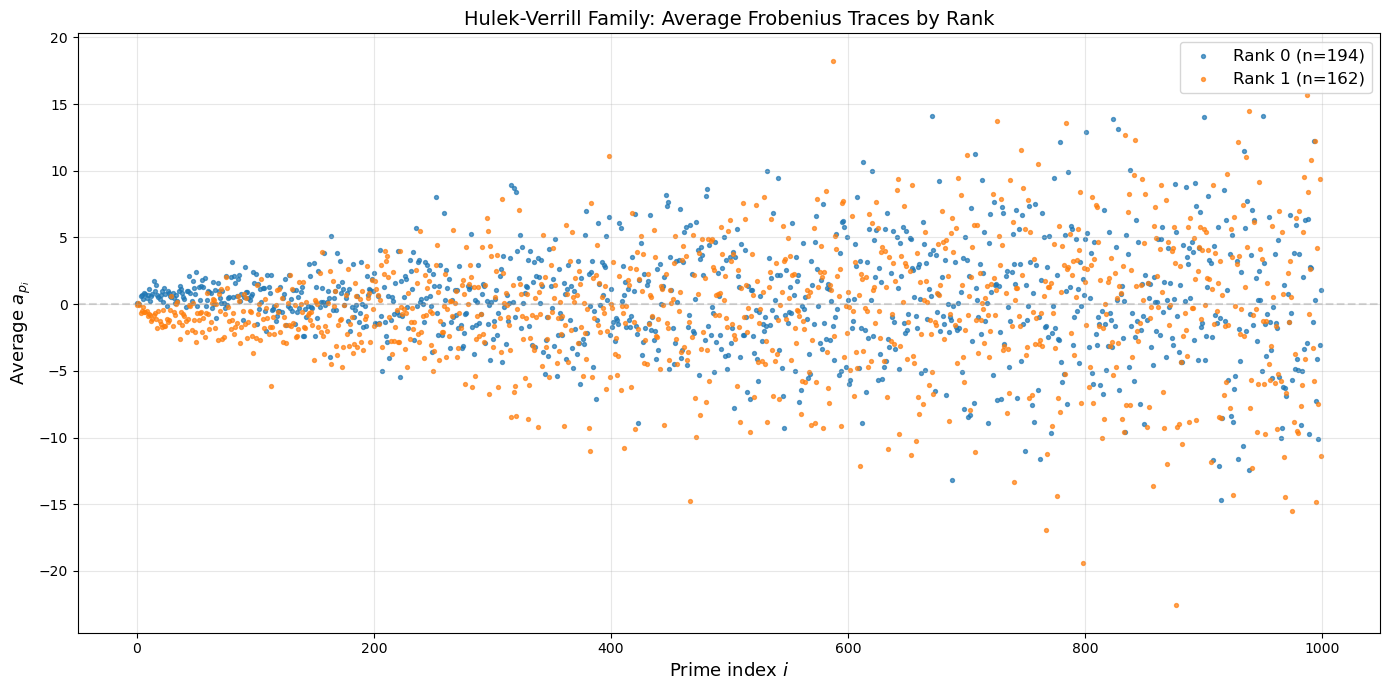

In [2]:
"""
Compute average Frobenius traces for Hulek-Verrill family
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# HV family
def hv_curve(phi):
    a = -27 * (9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1)
    b = -54 * (27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1)
    return EllipticCurve([0, 0, 0, a, b])

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

# Fraction sampling: phi = m/n with m in (-20, 20), n in (-10, 10)
print("Generating fraction phis...")
phis = set()
for m in range(-20, 21):
    for n in range(-20, 21):
        if n != 0:
            phis.add(QQ(m)/QQ(n))
phis = list(phis)
print(f"Generated {len(phis)} unique phi values")

# Process
print("Processing curves...")
iso_to_phis = {}
iso_to_data = {}
n_hits = 0
n_misses = 0

for phi in tqdm(phis):
    try:
        E = hv_curve(phi)
        iso = get_isogeny_class(E.label())
        
        if iso not in iso_to_phis:
            iso_to_phis[iso] = []
            curve = curve_db[iso]
            iso_to_data[iso] = {'rank': curve['rank'], 'aps': curve['ap_list']}
        iso_to_phis[iso].append(phi)
        n_hits += 1
    except:
        n_misses += 1
        continue

# Stats
n_distinct = len(iso_to_phis)
n_redundant = n_hits - n_distinct
efficiency = 100.0 * n_hits / len(phis)

print(f"\nTotal phis tried: {len(phis)}")
print(f"Hits (N < 100,000): {n_hits}")
print(f"Misses (N >= 100,000 or singular): {n_misses}")
print(f"Efficiency: {efficiency:.1f}%")
print(f"\nDistinct isogeny classes: {n_distinct}")
print(f"Redundant hits (same iso class): {n_redundant}")

# Multiplicity distribution
multiplicities = [len(v) for v in iso_to_phis.values()]
mult_counts = Counter(multiplicities)
print(f"\nMultiplicity distribution:")
for m in sorted(mult_counts.keys()):
    print(f"  {m}x: {mult_counts[m]} isogeny classes")

# Top multiplicities
print(f"\nTop 10 highest multiplicity isogeny classes:")
sorted_iso = sorted(iso_to_phis.items(), key=lambda x: len(x[1]), reverse=True)[:10]
for iso, phi_list in sorted_iso:
    print(f"  {iso}: {len(phi_list)} phis → {phi_list[:5]}{'...' if len(phi_list) > 5 else ''}")

# Extract aps by rank
rk0_aps, rk1_aps = [], []
for iso, data in iso_to_data.items():
    if data['rank'] == 0:
        rk0_aps.append(data['aps'])
    elif data['rank'] == 1:
        rk1_aps.append(data['aps'])

print(f"\nRank 0: {len(rk0_aps)} curves")
print(f"Rank 1: {len(rk1_aps)} curves")

# Average
rk0_avg = np.mean(rk0_aps, axis=0)
rk1_avg = np.mean(rk1_aps, axis=0)

# Save
save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg, 'n0': len(rk0_aps), 'n1': len(rk1_aps)}, 
     'Fast_Murmuration_Search/HV_avg_aps.sobj')
print("Saved to Fast_Murmuration_Search/HV_avg_aps.sobj")

# Plot
plt.figure(figsize=(14, 7))
plt.scatter(range(len(rk0_avg)), rk0_avg, s=8, alpha=0.7, label=f'Rank 0 (n={len(rk0_aps)})')
plt.scatter(range(len(rk1_avg)), rk1_avg, s=8, alpha=0.7, label=f'Rank 1 (n={len(rk1_aps)})')
plt.axhline(0, color='gray', ls='--', alpha=0.3)
plt.xlabel('Prime index $i$', fontsize=13)
plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
plt.title('Hulek-Verrill Family: Average Frobenius Traces by Rank', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_avg_aps.png', dpi=150)
plt.show()

HV family: 194 rank 0, 162 rank 1 curves

Fitting first 100 primes:

Rank 0 fit: 0.3649 * x^0.2199
  chi2 = 53.40

Rank 1 fit: -0.5106 * x^0.1622
  chi2 = 98.31

Total chi2 = 151.71


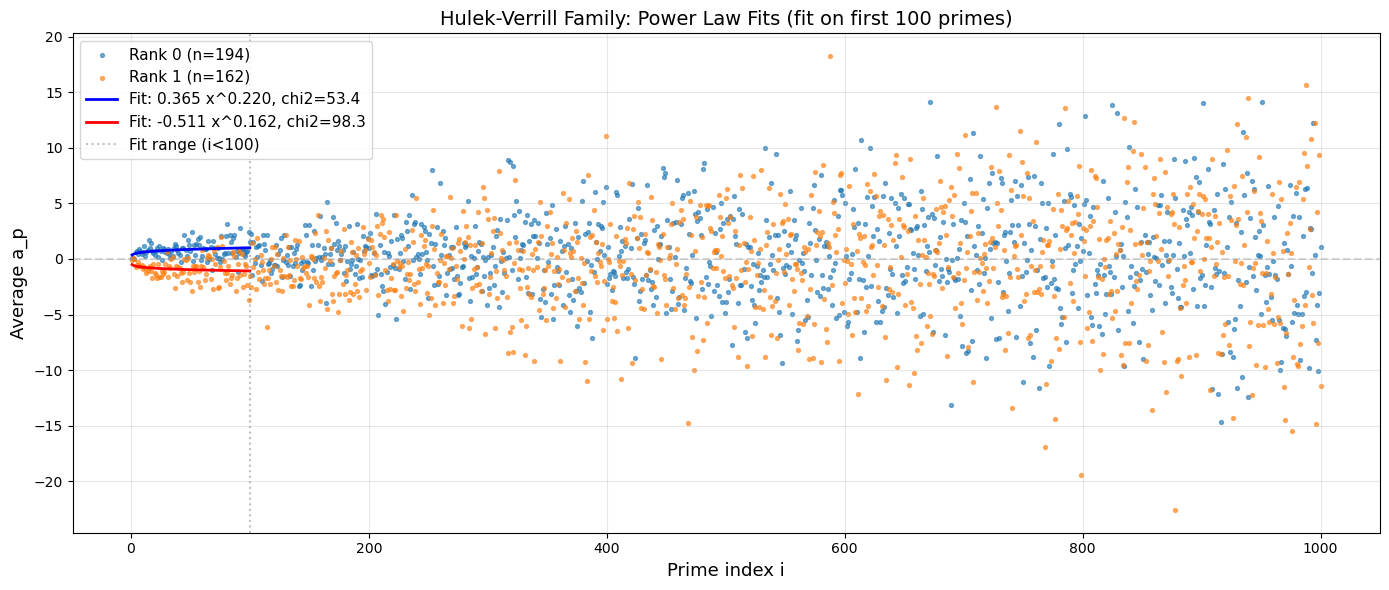


Drawing random sample from database...

Random sample rank 0 fit: 0.1969 * x^0.4335, chi2=119.91
Random sample rank 1 fit: -0.0512 * x^0.6573, chi2=155.67
Random total chi2 = 275.58

--- COMPARISON ---
HV total chi2:     151.71
Random total chi2: 275.58
HV is 1.82x cleaner than random


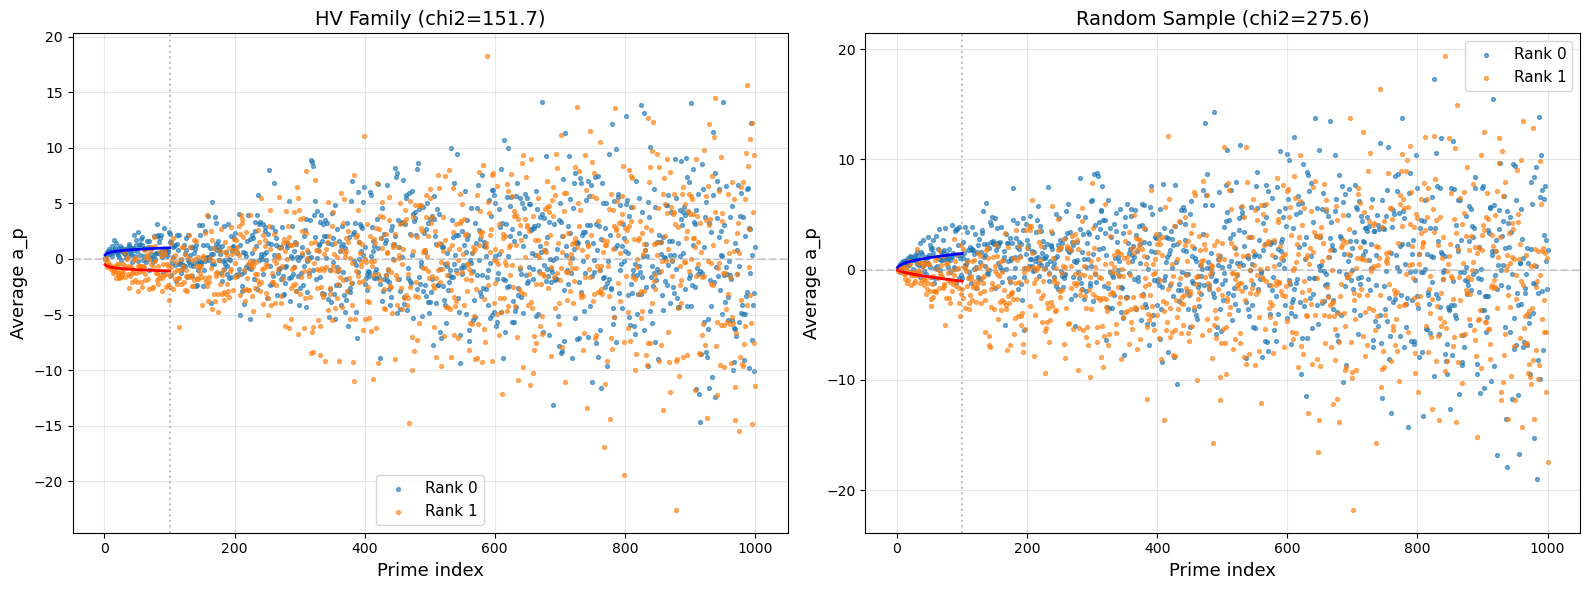

In [13]:
"""
Compare HV family murmuration vs random sample of same size
Fit with power law monomials x^alpha
"""
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit

# Load HV data
hv_data = load('Fast_Murmuration_Search/HV_avg_aps.sobj')
rk0_avg_hv = hv_data['rk0_avg']
rk1_avg_hv = hv_data['rk1_avg']
n0_hv = hv_data['n0']
n1_hv = hv_data['n1']

print(f"HV family: {n0_hv} rank 0, {n1_hv} rank 1 curves")

# Fit with power law: A * x^alpha
def power_law(x, A, alpha):
    return A * x**alpha

# Fit only first 100 primes
N_FIT = 100
x = np.arange(1, N_FIT + 1)
rk0_fit_data = rk0_avg_hv[:N_FIT]
rk1_fit_data = rk1_avg_hv[:N_FIT]

# Fit rank 0
popt0, pcov0 = curve_fit(power_law, x, rk0_fit_data, p0=[-1, 0.5], maxfev=10000)
A0, alpha0 = popt0
fit0 = power_law(x, A0, alpha0)
residuals0 = rk0_fit_data - fit0
chi2_0 = np.sum(residuals0**2)

# Fit rank 1
popt1, pcov1 = curve_fit(power_law, x, rk1_fit_data, p0=[1, 0.5], maxfev=10000)
A1, alpha1 = popt1
fit1 = power_law(x, A1, alpha1)
residuals1 = rk1_fit_data - fit1
chi2_1 = np.sum(residuals1**2)

print(f"\nFitting first {N_FIT} primes:")
print(f"\nRank 0 fit: {A0:.4f} * x^{alpha0:.4f}")
print(f"  chi2 = {chi2_0:.2f}")
print(f"\nRank 1 fit: {A1:.4f} * x^{alpha1:.4f}")
print(f"  chi2 = {chi2_1:.2f}")
print(f"\nTotal chi2 = {chi2_0 + chi2_1:.2f}")

# Plot with fits (all primes, fit on first 100)
x_all = np.arange(1, len(rk0_avg_hv) + 1)
x_fit = np.arange(1, N_FIT + 1)

plt.figure(figsize=(14, 6))
plt.scatter(x_all, rk0_avg_hv, s=8, alpha=0.6, label=f'Rank 0 (n={n0_hv})')
plt.scatter(x_all, rk1_avg_hv, s=8, alpha=0.6, label=f'Rank 1 (n={n1_hv})')
plt.plot(x_fit, fit0, 'b-', lw=2, label=f'Fit: {A0:.3f} x^{alpha0:.3f}, chi2={chi2_0:.1f}')
plt.plot(x_fit, fit1, 'r-', lw=2, label=f'Fit: {A1:.3f} x^{alpha1:.3f}, chi2={chi2_1:.1f}')
plt.axhline(0, color='gray', ls='--', alpha=0.3)
plt.axvline(N_FIT, color='gray', ls=':', alpha=0.5, label=f'Fit range (i<{N_FIT})')
plt.xlabel('Prime index i', fontsize=13)
plt.ylabel('Average a_p', fontsize=13)
plt.title(f'Hulek-Verrill Family: Power Law Fits (fit on first {N_FIT} primes)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_power_law_fit.png', dpi=150)
plt.show()

# Now compare with random sample
print("\n" + "="*60)
print("Drawing random sample from database...")

rk0_isos = [iso for iso, data in curve_db.items() if data['rank'] == 0]
rk1_isos = [iso for iso, data in curve_db.items() if data['rank'] == 1]

random.seed(int(42))
rk0_sample = random.sample(rk0_isos, n0_hv)
rk1_sample = random.sample(rk1_isos, n1_hv)

rk0_aps_rand = [curve_db[iso]['ap_list'] for iso in rk0_sample]
rk1_aps_rand = [curve_db[iso]['ap_list'] for iso in rk1_sample]

rk0_avg_rand = np.mean(rk0_aps_rand, axis=0)
rk1_avg_rand = np.mean(rk1_aps_rand, axis=0)

# Fit random sample (first N_FIT primes)
popt0_r, _ = curve_fit(power_law, x, rk0_avg_rand[:N_FIT], p0=[-1, 0.5], maxfev=10000)
A0_r, alpha0_r = popt0_r
fit0_r = power_law(x, A0_r, alpha0_r)
chi2_0_r = np.sum((rk0_avg_rand[:N_FIT] - fit0_r)**2)

popt1_r, _ = curve_fit(power_law, x, rk1_avg_rand[:N_FIT], p0=[1, 0.5], maxfev=10000)
A1_r, alpha1_r = popt1_r
fit1_r = power_law(x, A1_r, alpha1_r)
chi2_1_r = np.sum((rk1_avg_rand[:N_FIT] - fit1_r)**2)

print(f"\nRandom sample rank 0 fit: {A0_r:.4f} * x^{alpha0_r:.4f}, chi2={chi2_0_r:.2f}")
print(f"Random sample rank 1 fit: {A1_r:.4f} * x^{alpha1_r:.4f}, chi2={chi2_1_r:.2f}")
print(f"Random total chi2 = {chi2_0_r + chi2_1_r:.2f}")

print(f"\n--- COMPARISON ---")
print(f"HV total chi2:     {chi2_0 + chi2_1:.2f}")
print(f"Random total chi2: {chi2_0_r + chi2_1_r:.2f}")
print(f"HV is {(chi2_0_r + chi2_1_r)/(chi2_0 + chi2_1):.2f}x cleaner than random")

# Side by side plot (all primes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(x_all, rk0_avg_hv, s=8, alpha=0.6, label=f'Rank 0')
axes[0].scatter(x_all, rk1_avg_hv, s=8, alpha=0.6, label=f'Rank 1')
axes[0].plot(x_fit, fit0, 'b-', lw=2)
axes[0].plot(x_fit, fit1, 'r-', lw=2)
axes[0].axhline(0, color='gray', ls='--', alpha=0.3)
axes[0].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
axes[0].set_xlabel('Prime index', fontsize=13)
axes[0].set_ylabel('Average a_p', fontsize=13)
axes[0].set_title(f'HV Family (chi2={chi2_0+chi2_1:.1f})', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

x_all_rand = np.arange(1, len(rk0_avg_rand) + 1)
axes[1].scatter(x_all_rand, rk0_avg_rand, s=8, alpha=0.6, label=f'Rank 0')
axes[1].scatter(x_all_rand, rk1_avg_rand, s=8, alpha=0.6, label=f'Rank 1')
axes[1].plot(x_fit, fit0_r, 'b-', lw=2)
axes[1].plot(x_fit, fit1_r, 'r-', lw=2)
axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
axes[1].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
axes[1].set_xlabel('Prime index', fontsize=13)
axes[1].set_ylabel('Average a_p', fontsize=13)
axes[1].set_title(f'Random Sample (chi2={chi2_0_r+chi2_1_r:.1f})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_vs_random.png', dpi=150)
plt.show()

Discriminant Δ(φ) =
4096*(9*phi - 1)*(phi - 1)^3*phi^6

j-invariant j(φ) =
(3*phi^3 - 3*phi^2 + 9*phi - 1)^3*(3*phi - 1)^3/((9*phi - 1)*(phi - 1)^3*phi^6)

Numerical check: conductor vs φ

     φ |            N | log₁₀(N) |               Δ
--------------------------------------------------
   -10 |        10010 |     4.00 | 496111616000000
    -9 |         2460 |     3.39 | 178496151552000
    -8 |          438 |     2.64 | 57141318647808
    -7 |           14 |     1.15 | 15790581481472
    -6 |         2310 |     3.36 | 3605157642240
    -5 |         1380 |     3.14 | 635904000000
    -4 |          370 |     2.57 | 77594624000
    -3 |           84 |     1.92 | 5350883328
    -2 |          114 |     2.06 | 134479872
    -1 |           20 |     1.30 | 327680
     0 | ERROR: y^2 = x^3 - 1/3*x + 2/27 defines a singular curve
     1 | ERROR: y^2 = x^3 - 16/3*x + 128/27 defines a singular curve
     2 |           34 |     1.53 | 4456448
     3 |          156 |     2.19 | 621084672
     4 

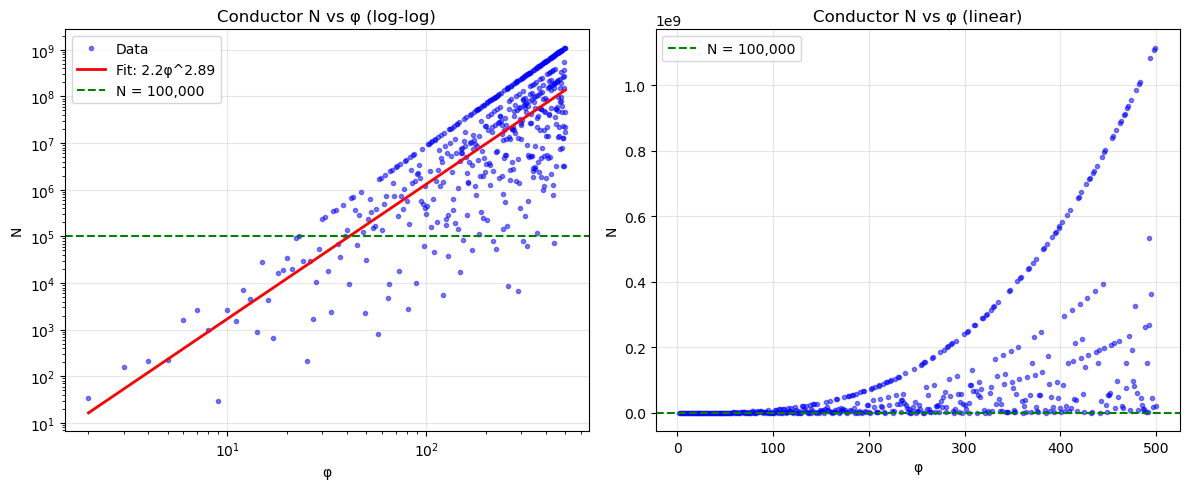

In [29]:
"""
Compute discriminant and conductor of HV family as function of φ
"""
var('phi')

# HV family coefficients (original Q(φ) form)
a = -(9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1) / 3
b = -2*(27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1) / 27

# Discriminant: Δ = -16(4a³ + 27b²)
Delta = -16 * (4*a**3 + 27*b**2)
Delta = Delta.expand()

print("Discriminant Δ(φ) =")
print(Delta.factor())

# Compute j-invariant symbolically: j = -1728 * (4a)³ / Δ
j_inv = -1728 * (4*a)**3 / Delta
j_inv = j_inv.simplify_full()
print("\nj-invariant j(φ) =")
print(j_inv.factor())

# Now check numerically for small phi values
print("\n" + "="*60)
print("Numerical check: conductor vs φ")
print("="*60)

def hv_curve(p):
    a_val = -(9*p**4 - 12*p**3 + 30*p**2 - 12*p + 1) / 3
    b_val = -2*(27*p**6 - 54*p**5 - 135*p**4 + 180*p**3 - 99*p**2 + 18*p - 1) / 27
    return EllipticCurve([0, 0, 0, a_val, b_val])

print(f"\n{'φ':>6} | {'N':>12} | {'log₁₀(N)':>8} | {'Δ':>15}")
print("-" * 50)

for p in list(range(-10, 11)) + [20, 50, 100, 200, 500, 1000]:
    try:
        E = hv_curve(p)
        N = E.conductor()
        d = E.discriminant()
        print(f"{p:>6} | {N:>12} | {float(log(N, 10)):>8.2f} | {d}")
    except Exception as e:
        print(f"{p:>6} | ERROR: {e}")

# Fit conductor growth
import numpy as np
import matplotlib.pyplot as plt

phi_vals = list(range(1, 501))
conductors = []
for p in phi_vals:
    try:
        E = hv_curve(p)
        conductors.append(int(E.conductor()))
    except:
        conductors.append(None)

# Filter valid
valid = [(p, N) for p, N in zip(phi_vals, conductors) if N is not None]
phi_arr = np.array([x[0] for x in valid])
N_arr = np.array([x[1] for x in valid])

# Log-log fit
log_phi = np.log(phi_arr)
log_N = np.log(N_arr)
coeffs = np.polyfit(log_phi, log_N, 1)
alpha = coeffs[0]
A = np.exp(coeffs[1])

print(f"\n\nPower law fit: N ≈ {A:.2f} × φ^{alpha:.2f}")
print(f"For N < 100,000, need φ < {(100000/A)**(1/alpha):.0f}")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.loglog(phi_arr, N_arr, 'b.', alpha=0.5, label='Data')
plt.loglog(phi_arr, A * phi_arr**alpha, 'r-', lw=2, label=f'Fit: {A:.1f}φ^{alpha:.2f}')
plt.axhline(100000, color='green', ls='--', label='N = 100,000')
plt.xlabel('φ')
plt.ylabel('N')
plt.title('Conductor N vs φ (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(phi_arr, N_arr, 'b.', alpha=0.5)
plt.axhline(100000, color='green', ls='--', label='N = 100,000')
plt.xlabel('φ')
plt.ylabel('N')
plt.title('Conductor N vs φ (linear)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_conductor_vs_phi.png', dpi=150)
plt.show()

Phis with N > φ^3.34: 157 out of 499

These phis:
[  2   3   4   5   6   7  10  12  15  18  19  20  22  23  30  31  34  35
  38  42  43  44  47  52  58  59  62  66  67  68  70  71  74  78  79  83
  86  87  95 102 103 106 107 110 111 115 119 123 130 131 134 138 142 143
 146 155 159 166 167 174 178 179 182 183 186 191 194 195 202 203 206 210
 211 215 218 219 222 223 227 230 231 238 247 254 255 258 259 266 267 274
 278 282 283 286 287 291 299 302 303 310 311 318 319 322 323 327 330 331
 335 346 347 355 358 359 366 367 371 374 382 383 386 391 394 395 398 399
 402 407 410 418 419 422 427 430 431 434 435 438 443 446 447 454 455 458
 462 463 466 467 470 471 474 479 482 483 494 498 499]


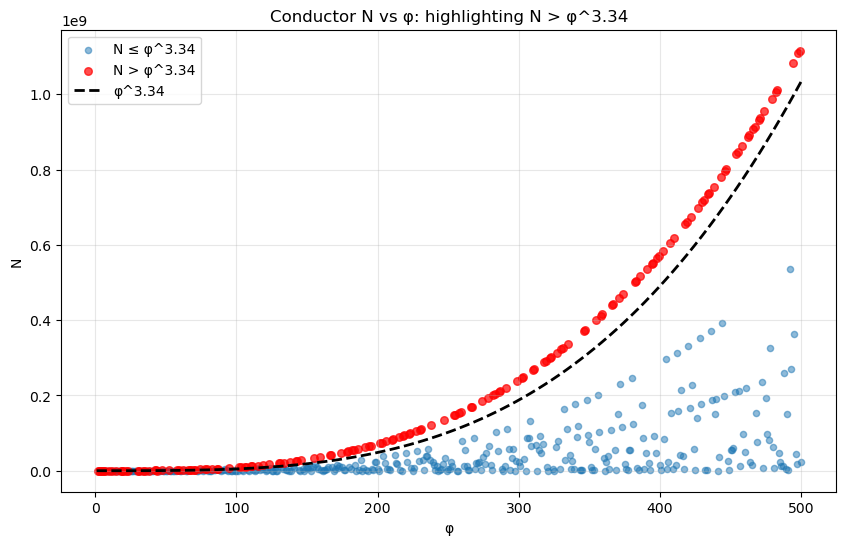

In [28]:
# Select phis where N > phi^3.34
threshold = lambda x: x**3.34

mask = N_arr > threshold(phi_arr)
phi_above = phi_arr[mask]
N_above = N_arr[mask]

print(f"Phis with N > φ^3.34: {len(phi_above)} out of {len(phi_arr)}")
print(f"\nThese phis:")
print(phi_above)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(phi_arr[~mask], N_arr[~mask], alpha=0.5, label='N ≤ φ^3.34', s=20)
plt.scatter(phi_above, N_above, alpha=0.7, c='red', label='N > φ^3.34', s=30)
plt.plot(np.linspace(1, 500, 100), threshold(np.linspace(1, 500, 100)), 'k--', lw=2, label='φ^3.34')
plt.xlabel('φ')
plt.ylabel('N')
plt.title('Conductor N vs φ: highlighting N > φ^3.34')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
"""
Track efficiency for different ranges of m and n
"""
from tqdm import tqdm

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

def hv_curve(phi):
    a = -27 * (9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1)
    b = -54 * (27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1)
    return EllipticCurve([0, 0, 0, a, b])

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

def scan_efficiency(r_m, r_n):
    """Compute efficiency for m in (-r_m, r_m), n in (-r_n, r_n)"""
    phis = set()
    for m in range(-r_m, r_m + 1):
        for n in range(-r_n, r_n + 1):
            if n != 0:
                phis.add(QQ(m)/QQ(n))
    phis = list(phis)
    
    iso_classes = set()
    n_hits = 0
    
    for phi in phis:
        try:
            E = hv_curve(phi)
            iso = get_isogeny_class(E.label())
            iso_classes.add(iso)
            n_hits += 1
        except:
            continue
    
    n_distinct = len(iso_classes)
    efficiency = 100.0 * n_hits / len(phis)
    redundancy = n_hits - n_distinct
    
    return {
        'r_m': r_m,
        'r_n': r_n,
        'n_phis': len(phis),
        'n_hits': n_hits,
        'n_distinct': n_distinct,
        'redundancy': redundancy,
        'efficiency': efficiency
    }

# Scan different ranges
r_values = [10, 20, 30, 40]
results = []

print(f"{'r_m':>5} | {'r_n':>5} | {'n_phis':>8} | {'hits':>6} | {'distinct':>8} | {'redund':>6} | {'eff %':>7}")
print("-" * 65)

for r in tqdm(r_values, desc="Scanning r values"):
    # Same r for both m and n
    res = scan_efficiency(r, r)
    results.append(res)
    print(f"{res['r_m']:>5} | {res['r_n']:>5} | {res['n_phis']:>8} | {res['n_hits']:>6} | {res['n_distinct']:>8} | {res['redundancy']:>6} | {res['efficiency']:>6.1f}%")

# Also try asymmetric: larger m, smaller n
print("\nAsymmetric ranges (larger m, smaller n):")
print(f"{'r_m':>5} | {'r_n':>5} | {'n_phis':>8} | {'hits':>6} | {'distinct':>8} | {'redund':>6} | {'eff %':>7}")
print("-" * 65)

asymmetric = [(30, 5), (40, 5), (50, 5), (60, 5), (50, 10), (100, 10)]
for r_m, r_n in tqdm(asymmetric, desc="Asymmetric scan"):
    res = scan_efficiency(r_m, r_n)
    results.append(res)
    print(f"{res['r_m']:>5} | {res['r_n']:>5} | {res['n_phis']:>8} | {res['n_hits']:>6} | {res['n_distinct']:>8} | {res['redundancy']:>6} | {res['efficiency']:>6.1f}%")

✓ curve_db loaded with 437226 isogeny classes
  r_m |   r_n |   n_phis |   hits | distinct | redund |   eff %
-----------------------------------------------------------------


Scanning r values:  25%|████████████████▌                                                 | 1/4 [00:09<00:28,  9.52s/it]

   10 |    10 |      127 |    124 |      106 |     18 |   97.6%


Scanning r values:  50%|█████████████████████████████████                                 | 2/4 [00:55<01:02, 31.01s/it]

   20 |    20 |      511 |    482 |      418 |     64 |   94.3%


...

   60 |     5 |      417 |    291 |      282 |      9 |   69.8%


Asymmetric scan:  83%|████████████████████████████████████████████████████████▋           | 5/6 [02:31<00:34, 34.98s/it]

   50 |    10 |      627 |    468 |      445 |     23 |   74.6%


Asymmetric scan: 100%|████████████████████████████████████████████████████████████████████| 6/6 [04:19<00:00, 43.29s/it]

  100 |    10 |     1247 |    598 |      574 |     24 |   48.0%


In [ ]:
"""
Genetic Algorithm for Fast-Murmurating Elliptic Curve Families
Fitness = 1 / chi2 from power law fits (higher = better)
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import random
import os

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# Parameters
N_FIT = 100        # Fit first 100 primes
MIN_CURVES = 50    # Minimum curves per rank

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

def generate_phis():
    """phi = m/n with m,n in (-20, 20)"""
    phis = set()
    for m in range(-20, 21):
        for n in range(-20, 21):
            if n != 0:
                phis.add(QQ(m)/QQ(n))
    return list(phis)

def power_law(x, A, alpha):
    return A * x**alpha

def compute_fitness(rk0_avg, rk1_avg):
    """Fitness = 1/chi2 from power law fits"""
    x = np.arange(1, N_FIT + 1)
    rk0_data = rk0_avg[:N_FIT]
    rk1_data = rk1_avg[:N_FIT]
    
    try:
        popt0, _ = curve_fit(power_law, x, rk0_data, p0=[0.3, 0.2], maxfev=5000)
        fit0 = power_law(x, *popt0)
        chi2_0 = np.sum((rk0_data - fit0)**2)
        
        popt1, _ = curve_fit(power_law, x, rk1_data, p0=[-0.5, 0.2], maxfev=5000)
        fit1 = power_law(x, *popt1)
        chi2_1 = np.sum((rk1_data - fit1)**2)
        
        total_chi2 = chi2_0 + chi2_1
        fitness = 1.0 / total_chi2 if total_chi2 > 0 else 0
        return fitness, total_chi2, popt0, popt1
    except:
        return 0, float('inf'), None, None

def hv_curve(phi):
    a = -27 * (9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1)
    b = -54 * (27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1)
    return EllipticCurve([0, 0, 0, a, b])

def curve_from_poly(phi, p4, p6):
    a = sum(c * phi**i for i, c in enumerate(p4))
    b = sum(d * phi**i for i, d in enumerate(p6))
    return EllipticCurve([0, 0, 0, a, b])

def evaluate_family(curve_func, phis):
    """Evaluate a curve family, return (fitness, chi2, n0, n1, rk0_avg, rk1_avg)"""
    seen_iso = set()
    rk0_aps, rk1_aps = [], []
    
    for phi in phis:
        try:
            E = curve_func(phi)
            iso = get_isogeny_class(E.label())
            if iso in seen_iso:
                continue
            seen_iso.add(iso)
            curve = curve_db[iso]
            rk = curve['rank']
            aps = curve['ap_list']
            if rk == 0:
                rk0_aps.append(aps)
            elif rk == 1:
                rk1_aps.append(aps)
        except:
            continue
    
    if len(rk0_aps) < MIN_CURVES or len(rk1_aps) < MIN_CURVES:
        return 0, float('inf'), len(rk0_aps), len(rk1_aps), None, None
    
    rk0_avg = np.mean(rk0_aps, axis=0)
    rk1_avg = np.mean(rk1_aps, axis=0)
    fitness, chi2, _, _ = compute_fitness(rk0_avg, rk1_avg)
    return fitness, chi2, len(rk0_aps), len(rk1_aps), rk0_avg, rk1_avg

class Family:
    def __init__(self, p4=None, p6=None):
        if p4 is None:
            self.p4 = [random.randint(-100, 100) for _ in range(5)]
            self.p6 = [random.randint(-100, 100) for _ in range(7)]
        else:
            self.p4 = list(p4)
            self.p6 = list(p6)
        self.fitness = None
        self.chi2 = None
        self.n0 = self.n1 = 0
        self.rk0_avg = self.rk1_avg = None
    
    def curve(self, phi):
        return curve_from_poly(phi, self.p4, self.p6)
    
    def evaluate(self, phis):
        self.fitness, self.chi2, self.n0, self.n1, self.rk0_avg, self.rk1_avg = \
            evaluate_family(self.curve, phis)
    
    def crossover(self, other):
        child_p4 = [int(round((a+b)/2)) for a, b in zip(self.p4, other.p4)]
        child_p6 = [int(round((a+b)/2)) for a, b in zip(self.p6, other.p6)]
        return Family(child_p4, child_p6)
    
    def mutate(self, rate=0.3, strength=20):
        for i in range(len(self.p4)):
            if random.random() < rate:
                self.p4[i] += random.randint(-strength, strength)
        for i in range(len(self.p6)):
            if random.random() < rate:
                self.p6[i] += random.randint(-strength, strength)

# HV family coefficients
HV_P4 = [-27, 324, -810, 324, -243]
HV_P6 = [54, -972, 5346, -9720, 7290, 2916, -1458]

def run_ga(n_gen=20, pop_size=10, elite=3, mut_rate=0.3, include_hv=True):
    print("="*60)
    print("GENETIC ALGORITHM: Fast Murmuration Search")
    print("="*60)
    
    phis = generate_phis()
    print(f"Generated {len(phis)} phis")
    
    # Initialize population
    print(f"\nInitializing population of {pop_size}...")
    pop = [Family() for _ in range(pop_size)]
    
    # Optionally include HV as one parent
    if include_hv:
        pop[0] = Family(HV_P4, HV_P6)
        print("Included HV family as initial parent")
    
    best_ever = None
    history = {'gen': [], 'best_fit': [], 'best_chi2': [], 'avg_fit': []}
    
    for gen in range(n_gen):
        print(f"\n--- Generation {gen+1}/{n_gen} ---")
        
        for ind in tqdm(pop, desc="Evaluating"):
            if ind.fitness is None:
                ind.evaluate(phis)
        
        # Filter valid individuals
        valid_pop = [p for p in pop if p.fitness and p.fitness > 0]
        if not valid_pop:
            print("No valid individuals, regenerating...")
            pop = [Family() for _ in range(pop_size)]
            continue
        
        valid_pop.sort(key=lambda x: x.fitness, reverse=True)
        best = valid_pop[0]
        avg_fit = np.mean([p.fitness for p in valid_pop])
        
        if best_ever is None or best.fitness > best_ever.fitness:
            best_ever = Family(best.p4, best.p6)
            best_ever.fitness = best.fitness
            best_ever.chi2 = best.chi2
            best_ever.n0, best_ever.n1 = best.n0, best.n1
            best_ever.rk0_avg, best_ever.rk1_avg = best.rk0_avg, best.rk1_avg
        
        history['gen'].append(gen + 1)
        history['best_fit'].append(best.fitness)
        history['best_chi2'].append(best.chi2)
        history['avg_fit'].append(avg_fit)
        
        print(f"Best: chi2={best.chi2:.2f}, n={best.n0}+{best.n1}")
        print(f"  p4={best.p4}")
        print(f"  p6={best.p6}")
        
        if gen < n_gen - 1:
            # Selection from valid population only
            n_elite = min(elite, len(valid_pop))
            elites = valid_pop[:n_elite]
            new_pop = [Family(e.p4, e.p6) for e in elites]  # Copy elites
            
            while len(new_pop) < pop_size:
                if len(elites) >= 2:
                    p1, p2 = random.sample(elites, 2)
                else:
                    p1 = elites[0]
                    p2 = Family()  # Random if only one elite
                child = p1.crossover(p2)
                child.mutate(rate=mut_rate)
                new_pop.append(child)
            
            # Add fresh random individuals
            n_fresh = max(2, pop_size // 5)
            for i in range(n_fresh):
                new_pop[-(i+1)] = Family()
            
            pop = new_pop
    
    # Final comparison with HV
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    
    print(f"\nBest family found:")
    print(f"  p4 = {best_ever.p4}")
    print(f"  p6 = {best_ever.p6}")
    print(f"  chi2 = {best_ever.chi2:.2f}")
    print(f"  curves: {best_ever.n0} rank 0, {best_ever.n1} rank 1")
    
    # Now evaluate HV for comparison
    print("\nEvaluating HV family for comparison...")
    hv_fit, hv_chi2, hv_n0, hv_n1, hv_rk0, hv_rk1 = evaluate_family(hv_curve, phis)
    print(f"HV family: chi2={hv_chi2:.2f}, n0={hv_n0}, n1={hv_n1}")
    
    if best_ever.chi2 < hv_chi2:
        print(f"\n*** FOUND BETTER FAMILY! {hv_chi2/best_ever.chi2:.2f}x cleaner than HV ***")
    else:
        print(f"\nHV family is {best_ever.chi2/hv_chi2:.2f}x cleaner than best found")
    
    # Save
    save({'best_p4': best_ever.p4, 'best_p6': best_ever.p6, 
          'best_chi2': best_ever.chi2, 'hv_chi2': hv_chi2, 'history': history},
         'Fast_Murmuration_Search/ga_results.sobj')
    
    # Plot evolution
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.semilogy(history['gen'], history['best_chi2'], 'b-o', lw=2, label='Best chi2')
    ax.axhline(hv_chi2, color='red', ls='--', lw=2, label=f'HV baseline ({hv_chi2:.1f})')
    ax.set_xlabel('Generation')
    ax.set_ylabel('chi2 (log scale)')
    ax.set_title('GA Evolution: Searching for Fastest Murmuration')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('Fast_Murmuration_Search/ga_evolution.png', dpi=150)
    plt.show()
    
    # Plot best vs HV
    if best_ever.rk0_avg is not None and hv_rk0 is not None:
        x = np.arange(1, len(best_ever.rk0_avg) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        axes[0].scatter(x, best_ever.rk0_avg, s=8, alpha=0.6, label='Rank 0')
        axes[0].scatter(x, best_ever.rk1_avg, s=8, alpha=0.6, label='Rank 1')
        axes[0].axhline(0, color='gray', ls='--', alpha=0.3)
        axes[0].set_xlabel('Prime index')
        axes[0].set_ylabel('Average a_p')
        axes[0].set_title(f'Best GA Family (chi2={best_ever.chi2:.1f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].scatter(x, hv_rk0, s=8, alpha=0.6, label='Rank 0')
        axes[1].scatter(x, hv_rk1, s=8, alpha=0.6, label='Rank 1')
        axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
        axes[1].set_xlabel('Prime index')
        axes[1].set_ylabel('Average a_p')
        axes[1].set_title(f'HV Family (chi2={hv_chi2:.1f})')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('Fast_Murmuration_Search/best_vs_hv.png', dpi=150)
        plt.show()
    
    return best_ever, hv_chi2, history

# Run
best, hv_chi2, history = run_ga(n_gen=20, pop_size=10, elite=3, mut_rate=0.3, include_hv=False)

In [19]:
"""
Complete suite for analyzing elliptic curve families and comparing to random samples
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
import random
from scipy.optimize import curve_fit

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")


# ============================================================================
# FAMILY DEFINITION AND ANALYSIS
# ============================================================================

class EllipticCurveFamily:
    """
    Define an elliptic curve family E: y^2 = x^3 + a(phi)*x + b(phi)
    
    Parameters:
    -----------
    a_coeffs : dict
        Coefficients for a(phi) as {power: coefficient}
        Example: {4: 9, 3: -12, 2: 30, 1: -12, 0: 1} for 9*phi^4 - 12*phi^3 + ...
    b_coeffs : dict
        Coefficients for b(phi) as {power: coefficient}
    name : str
        Name of the family for labeling plots/files
    """
    
    def __init__(self, a_coeffs, b_coeffs, name="CustomFamily"):
        self.a_coeffs = a_coeffs
        self.b_coeffs = b_coeffs
        self.name = name
        
        # Create polynomial ring
        R.<phi> = QQ[]
        self.a_poly = sum(coef * phi^pow for pow, coef in a_coeffs.items())
        self.b_poly = sum(coef * phi^pow for pow, coef in b_coeffs.items())
        
        print(f"Family: {name}")
        print(f"a(φ) = {self.a_poly}")
        print(f"b(φ) = {self.b_poly}")
    
    def curve(self, phi_val):
        """Compute elliptic curve for given phi value"""
        a_val = self.a_poly(phi_val)
        b_val = self.b_poly(phi_val)
        return EllipticCurve([0, 0, 0, a_val, b_val])


def get_isogeny_class(label):
    """Extract isogeny class from curve label"""
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]


def analyze_family(family, phi_range_m=(-20, 21), phi_range_n=(-20, 21), 
                   output_prefix=None):
    """
    Analyze an elliptic curve family over rational phi values
    """
    
    if output_prefix is None:
        output_prefix = family.name
    
    # Generate fraction phis: phi = m/n
    print(f"\nGenerating fraction phis from {phi_range_m} / {phi_range_n}...")
    phis = set()
    for m in range(*phi_range_m):
        for n in range(*phi_range_n):
            if n != 0:
                phis.add(QQ(m)/QQ(n))
    phis = list(phis)
    print(f"Generated {len(phis)} unique phi values")
    
    # Process curves
    print("Processing curves...")
    iso_to_phis = {}
    iso_to_data = {}
    n_hits = 0
    n_misses = 0
    
    for phi in tqdm(phis):
        try:
            E = family.curve(phi)
            iso = get_isogeny_class(E.label())
            
            # FIX: Only add to iso_to_phis if it's actually in the database
            if iso in curve_db:
                if iso not in iso_to_phis:
                    iso_to_phis[iso] = []
                    curve = curve_db[iso]
                    iso_to_data[iso] = {'rank': curve['rank'], 'aps': curve['ap_list']}
                iso_to_phis[iso].append(phi)
                n_hits += 1
            else:
                n_misses += 1
        except:
            n_misses += 1
            continue
    
    # Statistics
    n_distinct = len(iso_to_phis)
    n_redundant = n_hits - n_distinct
    efficiency = 100.0 * n_hits / len(phis) if len(phis) > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"RESULTS FOR {family.name}")
    print(f"{'='*60}")
    print(f"Total phis tried: {len(phis)}")
    print(f"Hits (N < 100,000): {n_hits}")
    print(f"Misses (N >= 100,000 or singular): {n_misses}")
    print(f"Efficiency: {efficiency:.1f}%")
    print(f"\nDistinct isogeny classes: {n_distinct}")
    print(f"Redundant hits (same iso class): {n_redundant}")
    
    # Multiplicity distribution
    multiplicities = [len(v) for v in iso_to_phis.values()]
    mult_counts = Counter(multiplicities)
    print(f"\nMultiplicity distribution:")
    for m in sorted(mult_counts.keys()):
        print(f"  {m}x: {mult_counts[m]} isogeny classes")
    
    # Top multiplicities
    print(f"\nTop 10 highest multiplicity isogeny classes:")
    sorted_iso = sorted(iso_to_phis.items(), key=lambda x: len(x[1]), reverse=True)[:10]
    for iso, phi_list in sorted_iso:
        print(f"  {iso}: {len(phi_list)} phis → {phi_list[:5]}{'...' if len(phi_list) > 5 else ''}")
    
    # Extract aps by rank
    rk0_aps, rk1_aps = [], []
    for iso, data in iso_to_data.items():
        if data['rank'] == 0:
            rk0_aps.append(data['aps'])
        elif data['rank'] == 1:
            rk1_aps.append(data['aps'])
    
    print(f"\nRank 0: {len(rk0_aps)} curves")
    print(f"Rank 1: {len(rk1_aps)} curves")
    
    # Need at least a few curves for meaningful analysis
    min_curves_needed = 10
    if len(rk0_aps) + len(rk1_aps) < min_curves_needed:
        print(f"\n⚠ Warning: Only {len(rk0_aps) + len(rk1_aps)} curves found.")
        print(f"Need at least {min_curves_needed} for meaningful murmuration analysis.")
        print("Skipping averaging and plotting.")
        return None
    
    # Average
    rk0_avg = np.mean(rk0_aps, axis=0) if len(rk0_aps) > 0 else np.array([])
    rk1_avg = np.mean(rk1_aps, axis=0) if len(rk1_aps) > 0 else np.array([])
    
    # Save
    save_path = f'Fast_Murmuration_Search/{output_prefix}_avg_aps.sobj'
    save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg, 
          'n0': len(rk0_aps), 'n1': len(rk1_aps),
          'family_name': family.name,
          'a_coeffs': family.a_coeffs,
          'b_coeffs': family.b_coeffs}, save_path)
    print(f"\nSaved to {save_path}")
    
    # Plot
    plt.figure(figsize=(14, 7))
    if len(rk0_aps) > 0:
        plt.scatter(range(len(rk0_avg)), rk0_avg, s=8, alpha=0.7, 
                   label=f'Rank 0 (n={len(rk0_aps)})')
    if len(rk1_aps) > 0:
        plt.scatter(range(len(rk1_avg)), rk1_avg, s=8, alpha=0.7, 
                   label=f'Rank 1 (n={len(rk1_aps)})')
    plt.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.xlabel('Prime index $i$', fontsize=13)
    plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
    plt.title(f'{family.name}: Average Frobenius Traces by Rank', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plot_path = f'Fast_Murmuration_Search/{output_prefix}_avg_aps.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Plot saved to {plot_path}")
    
    return {
        'iso_to_phis': iso_to_phis,
        'iso_to_data': iso_to_data,
        'rk0_avg': rk0_avg,
        'rk1_avg': rk1_avg,
        'stats': {
            'n_phis': len(phis),
            'n_hits': n_hits,
            'n_misses': n_misses,
            'n_distinct': n_distinct,
            'efficiency': efficiency
        }
    }


# ============================================================================
# COMPARISON TO RANDOM SAMPLES
# ============================================================================

def power_law(x, A, alpha):
    """Power law function: A * x^alpha"""
    return A * x**alpha


def compare_family_to_random(family_name, data_path=None, n_fit=100, seed=42,
                             output_dir='Fast_Murmuration_Search'):
    """
    Compare a family's murmuration to a random sample of the same size
    
    Parameters:
    -----------
    family_name : str
        Name of the family (used for loading data if data_path not provided)
    data_path : str, optional
        Path to the saved .sobj file. If None, uses family_name to construct path
    n_fit : int
        Number of first primes to use for fitting
    seed : int
        Random seed for reproducibility
    output_dir : str
        Directory for saving plots
    """
    
    # Load family data
    if data_path is None:
        data_path = f'{output_dir}/{family_name}_avg_aps.sobj'
    
    print(f"Loading data from {data_path}...")
    family_data = load(data_path)
    
    rk0_avg_fam = family_data['rk0_avg']
    rk1_avg_fam = family_data['rk1_avg']
    n0_fam = family_data['n0']
    n1_fam = family_data['n1']
    
    display_name = family_data.get('family_name', family_name)
    
    print(f"\n{display_name} family: {n0_fam} rank 0, {n1_fam} rank 1 curves")
    
    if n0_fam == 0 and n1_fam == 0:
        print("No curves found with rank 0 or 1. Cannot perform comparison.")
        return None
    
    # Prepare fitting data
    N_FIT = min(int(n_fit), len(rk0_avg_fam), len(rk1_avg_fam))
    x = np.arange(1, N_FIT + 1)
    
    # Fit family data
    print(f"\nFitting first {N_FIT} primes for {display_name}...")
    
    results = {}
    
    # Rank 0 fit (if available)
    if n0_fam > 0 and len(rk0_avg_fam) >= N_FIT:
        rk0_fit_data = rk0_avg_fam[:N_FIT]
        try:
            popt0, pcov0 = curve_fit(power_law, x, rk0_fit_data, p0=[-1, 0.5], maxfev=10000)
            A0, alpha0 = popt0
            fit0 = power_law(x, A0, alpha0)
            residuals0 = rk0_fit_data - fit0
            chi2_0 = np.sum(residuals0**2)
            
            print(f"\nRank 0 fit: {A0:.4f} * x^{alpha0:.4f}")
            print(f"  chi2 = {chi2_0:.2f}")
            
            results['rk0'] = {
                'A': A0, 'alpha': alpha0, 'chi2': chi2_0,
                'fit': fit0, 'popt': popt0
            }
        except Exception as e:
            print(f"Rank 0 fit failed: {e}")
            results['rk0'] = None
    else:
        results['rk0'] = None
    
    # Rank 1 fit (if available)
    if n1_fam > 0 and len(rk1_avg_fam) >= N_FIT:
        rk1_fit_data = rk1_avg_fam[:N_FIT]
        try:
            popt1, pcov1 = curve_fit(power_law, x, rk1_fit_data, p0=[1, 0.5], maxfev=10000)
            A1, alpha1 = popt1
            fit1 = power_law(x, A1, alpha1)
            residuals1 = rk1_fit_data - fit1
            chi2_1 = np.sum(residuals1**2)
            
            print(f"\nRank 1 fit: {A1:.4f} * x^{alpha1:.4f}")
            print(f"  chi2 = {chi2_1:.2f}")
            
            results['rk1'] = {
                'A': A1, 'alpha': alpha1, 'chi2': chi2_1,
                'fit': fit1, 'popt': popt1
            }
        except Exception as e:
            print(f"Rank 1 fit failed: {e}")
            results['rk1'] = None
    else:
        results['rk1'] = None
    
    # Total chi2 for family
    chi2_fam_total = 0
    if results['rk0'] is not None:
        chi2_fam_total += results['rk0']['chi2']
    if results['rk1'] is not None:
        chi2_fam_total += results['rk1']['chi2']
    
    print(f"\nTotal chi2 for {display_name} = {chi2_fam_total:.2f}")
    
    # Random sample comparison
    print("\n" + "="*60)
    print("Drawing random sample from database...")
    
    rk0_isos = [iso for iso, data in curve_db.items() if data['rank'] == 0]
    rk1_isos = [iso for iso, data in curve_db.items() if data['rank'] == 1]
    
    random.seed(int(seed))  # FIX: Convert to Python int
    
    # Sample random curves
    rk0_aps_rand = []
    rk1_aps_rand = []
    rk0_avg_rand = np.array([])
    rk1_avg_rand = np.array([])
    
    if n0_fam > 0:
        rk0_sample = random.sample(rk0_isos, n0_fam)
        rk0_aps_rand = [curve_db[iso]['ap_list'] for iso in rk0_sample]
        rk0_avg_rand = np.mean(rk0_aps_rand, axis=0)
    
    if n1_fam > 0:
        rk1_sample = random.sample(rk1_isos, n1_fam)
        rk1_aps_rand = [curve_db[iso]['ap_list'] for iso in rk1_sample]
        rk1_avg_rand = np.mean(rk1_aps_rand, axis=0)
    
    # Fit random sample
    print(f"\nFitting random sample (first {N_FIT} primes)...")
    
    results_rand = {}
    
    # Rank 0 random fit
    if n0_fam > 0 and len(rk0_avg_rand) >= N_FIT:
        try:
            popt0_r, _ = curve_fit(power_law, x, rk0_avg_rand[:N_FIT], p0=[-1, 0.5], maxfev=10000)
            A0_r, alpha0_r = popt0_r
            fit0_r = power_law(x, A0_r, alpha0_r)
            chi2_0_r = np.sum((rk0_avg_rand[:N_FIT] - fit0_r)**2)
            
            print(f"Random sample rank 0 fit: {A0_r:.4f} * x^{alpha0_r:.4f}, chi2={chi2_0_r:.2f}")
            
            results_rand['rk0'] = {
                'A': A0_r, 'alpha': alpha0_r, 'chi2': chi2_0_r,
                'fit': fit0_r, 'popt': popt0_r
            }
        except Exception as e:
            print(f"Random rank 0 fit failed: {e}")
            results_rand['rk0'] = None
    else:
        results_rand['rk0'] = None
    
    # Rank 1 random fit
    if n1_fam > 0 and len(rk1_avg_rand) >= N_FIT:
        try:
            popt1_r, _ = curve_fit(power_law, x, rk1_avg_rand[:N_FIT], p0=[1, 0.5], maxfev=10000)
            A1_r, alpha1_r = popt1_r
            fit1_r = power_law(x, A1_r, alpha1_r)
            chi2_1_r = np.sum((rk1_avg_rand[:N_FIT] - fit1_r)**2)
            
            print(f"Random sample rank 1 fit: {A1_r:.4f} * x^{alpha1_r:.4f}, chi2={chi2_1_r:.2f}")
            
            results_rand['rk1'] = {
                'A': A1_r, 'alpha': alpha1_r, 'chi2': chi2_1_r,
                'fit': fit1_r, 'popt': popt1_r
            }
        except Exception as e:
            print(f"Random rank 1 fit failed: {e}")
            results_rand['rk1'] = None
    else:
        results_rand['rk1'] = None
    
    # Total chi2 for random
    chi2_rand_total = 0
    if results_rand['rk0'] is not None:
        chi2_rand_total += results_rand['rk0']['chi2']
    if results_rand['rk1'] is not None:
        chi2_rand_total += results_rand['rk1']['chi2']
    
    print(f"Random total chi2 = {chi2_rand_total:.2f}")
    
    # Comparison
    print(f"\n{'='*60}")
    print(f"--- COMPARISON ---")
    print(f"{display_name} total chi2:     {chi2_fam_total:.2f}")
    print(f"Random total chi2: {chi2_rand_total:.2f}")
    
    if chi2_fam_total > 0:
        ratio = chi2_rand_total / chi2_fam_total
        print(f"{display_name} is {ratio:.2f}x cleaner than random")
    else:
        ratio = None
        print("Cannot compute ratio (family chi2 is 0)")
    
    # ========================================================================
    # PLOTTING
    # ========================================================================
    
    # Plot 1: Family data with fits
    x_all = np.arange(1, max(len(rk0_avg_fam), len(rk1_avg_fam)) + 1)
    x_fit = np.arange(1, N_FIT + 1)
    
    plt.figure(figsize=(14, 6))
    
    if n0_fam > 0:
        plt.scatter(x_all[:len(rk0_avg_fam)], rk0_avg_fam, s=8, alpha=0.6, 
                   label=f'Rank 0 (n={n0_fam})')
        if results['rk0'] is not None:
            plt.plot(x_fit, results['rk0']['fit'], 'b-', lw=2, 
                    label=f"Fit: {results['rk0']['A']:.3f} x^{results['rk0']['alpha']:.3f}, chi2={results['rk0']['chi2']:.1f}")
    
    if n1_fam > 0:
        plt.scatter(x_all[:len(rk1_avg_fam)], rk1_avg_fam, s=8, alpha=0.6, 
                   label=f'Rank 1 (n={n1_fam})')
        if results['rk1'] is not None:
            plt.plot(x_fit, results['rk1']['fit'], 'r-', lw=2, 
                    label=f"Fit: {results['rk1']['A']:.3f} x^{results['rk1']['alpha']:.3f}, chi2={results['rk1']['chi2']:.1f}")
    
    plt.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.axvline(N_FIT, color='gray', ls=':', alpha=0.5, label=f'Fit range (i<{N_FIT})')
    plt.xlabel('Prime index i', fontsize=13)
    plt.ylabel('Average a_p', fontsize=13)
    plt.title(f'{display_name} Family: Power Law Fits (fit on first {N_FIT} primes)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plot_path1 = f'{output_dir}/{family_name}_power_law_fit.png'
    plt.savefig(plot_path1, dpi=150)
    print(f"\nSaved power law fit plot to {plot_path1}")
    plt.show()
    
    # Plot 2: Side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Family
    if n0_fam > 0:
        axes[0].scatter(x_all[:len(rk0_avg_fam)], rk0_avg_fam, s=8, alpha=0.6, label='Rank 0')
        if results['rk0'] is not None:
            axes[0].plot(x_fit, results['rk0']['fit'], 'b-', lw=2)
    
    if n1_fam > 0:
        axes[0].scatter(x_all[:len(rk1_avg_fam)], rk1_avg_fam, s=8, alpha=0.6, label='Rank 1')
        if results['rk1'] is not None:
            axes[0].plot(x_fit, results['rk1']['fit'], 'r-', lw=2)
    
    axes[0].axhline(0, color='gray', ls='--', alpha=0.3)
    axes[0].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
    axes[0].set_xlabel('Prime index', fontsize=13)
    axes[0].set_ylabel('Average a_p', fontsize=13)
    axes[0].set_title(f'{display_name} Family (chi2={chi2_fam_total:.1f})', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Right: Random
    x_all_rand = np.arange(1, max(len(rk0_avg_rand) if n0_fam > 0 else 0, 
                                   len(rk1_avg_rand) if n1_fam > 0 else 0) + 1)
    
    if n0_fam > 0:
        axes[1].scatter(x_all_rand[:len(rk0_avg_rand)], rk0_avg_rand, s=8, alpha=0.6, label='Rank 0')
        if results_rand['rk0'] is not None:
            axes[1].plot(x_fit, results_rand['rk0']['fit'], 'b-', lw=2)
    
    if n1_fam > 0:
        axes[1].scatter(x_all_rand[:len(rk1_avg_rand)], rk1_avg_rand, s=8, alpha=0.6, label='Rank 1')
        if results_rand['rk1'] is not None:
            axes[1].plot(x_fit, results_rand['rk1']['fit'], 'r-', lw=2)
    
    axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
    axes[1].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
    axes[1].set_xlabel('Prime index', fontsize=13)
    axes[1].set_ylabel('Average a_p', fontsize=13)
    axes[1].set_title(f'Random Sample (chi2={chi2_rand_total:.1f})', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    plot_path2 = f'{output_dir}/{family_name}_vs_random.png'
    plt.savefig(plot_path2, dpi=150)
    print(f"Saved comparison plot to {plot_path2}")
    plt.show()
    
    # Return summary
    return {
        'family_name': display_name,
        'family_results': results,
        'random_results': results_rand,
        'family_chi2': chi2_fam_total,
        'random_chi2': chi2_rand_total,
        'improvement_ratio': ratio,
        'n0': n0_fam,
        'n1': n1_fam,
        'n_fit': N_FIT
    }


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

print("\n" + "="*60)
print("READY TO USE!")
print("="*60)
print("\nExample 1: Hulek-Verrill family")
print("-" * 40)

✓ curve_db loaded with 437226 isogeny classes

READY TO USE!

Example 1: Hulek-Verrill family
----------------------------------------


In [20]:
import random

# TUNABLE PARAMETER: Adjust this to control coefficient range [-R, R]
R = 50  # Coefficients will be drawn from [-R, R]

def check_family_viability(a_coeffs, b_coeffs, n_samples=20):
    """
    Check if a family produces curves with conductor < 100,000
    by sampling a few phi values
    """
    R.<phi> = QQ[]
    a_poly = sum(coef * phi^pow for pow, coef in a_coeffs.items())
    b_poly = sum(coef * phi^pow for pow, coef in b_coeffs.items())
    
    # Sample some phi values
    test_phis = []
    for m in range(-5, 6):
        for n in range(1, 6):
            test_phis.append(QQ(m)/QQ(n))
    
    min_conductor = float('inf')
    viable_count = 0
    
    for phi_val in test_phis[:n_samples]:
        try:
            a_val = a_poly(phi_val)
            b_val = b_poly(phi_val)
            E = EllipticCurve([0, 0, 0, a_val, b_val])
            
            # Get conductor
            N = E.conductor()
            min_conductor = min(min_conductor, N)
            
            if N < 100000:
                viable_count += 1
        except:
            continue
    
    return viable_count > 0, min_conductor, viable_count

# Try to find a viable family
max_attempts = 50
print(f"Searching for viable family with R={R}...")
print(f"Target: conductor < 100,000\n")

for attempt in range(max_attempts):
    random.seed(int(attempt))
    
    # Generate random coefficients
    a_coeffs = {
        0: random.randint(-R, R),
        1: random.randint(-R, R),
        2: random.randint(-R, R),
        3: random.randint(-R, R),
        4: random.randint(-R, R)
    }
    
    b_coeffs = {
        0: random.randint(-R, R),
        1: random.randint(-R, R),
        2: random.randint(-R, R),
        3: random.randint(-R, R),
        4: random.randint(-R, R),
        5: random.randint(-R, R),
        6: random.randint(-R, R)
    }
    
    # Check viability
    is_viable, min_cond, n_viable = check_family_viability(a_coeffs, b_coeffs)
    
    print(f"Attempt {attempt+1}: min conductor = {min_cond}, viable curves = {n_viable}", end='')
    
    if is_viable:
        print(f" ✓ VIABLE!\n")
        print(f"{'='*70}")
        print(f"Found viable family!")
        print(f"{'='*70}")
        print(f"a(φ) coefficients: {a_coeffs}")
        print(f"b(φ) coefficients: {b_coeffs}\n")
        
        # Create and analyze the family
        my_family = EllipticCurveFamily(
            a_coeffs=a_coeffs,
            b_coeffs=b_coeffs,
            name="ViableRandomFamily"
        )
        
        result = analyze_family(my_family, phi_range_m=(-20, 21), phi_range_n=(-20, 21))
        
        # If we got hits, do the comparison
        if result is not None and result['stats']['n_hits'] > 0:
            print(f"\n{'='*70}")
            print(f"SUCCESS! Found {result['stats']['n_hits']} curves in database")
            print(f"Proceeding with Frobenius analysis...")
            print(f"{'='*70}\n")
            
            comparison = compare_family_to_random('ViableRandomFamily', n_fit=100)
            
            if comparison is not None and comparison['improvement_ratio'] is not None:
                print(f"\n{'='*70}")
                print(f"FINAL RESULT")
                print(f"{'='*70}")
                print(f"Improvement ratio: {comparison['improvement_ratio']:.2f}x cleaner than random")
                print(f"Family chi²: {comparison['family_chi2']:.2f}")
                print(f"Random chi²: {comparison['random_chi2']:.2f}")
        else:
            print(f"\n⚠ Family was viable but produced no hits in full analysis")
            print(f"Continuing search...")
            continue
        
        break
    else:
        print(f" ✗")
else:
    print(f"\n⚠ After {max_attempts} attempts, no viable family found.")
    print(f"Try decreasing R (currently R={R})")

Searching for viable family with R=50...
Target: conductor < 100,000

Attempt 1: min conductor = 410240, viable curves = 0 ✗
Attempt 2: min conductor = 732592, viable curves = 0 ✗
Attempt 3: min conductor = 4322052, viable curves = 0 ✗
Attempt 4: min conductor = 3906800, viable curves = 0 ✗
Attempt 5: min conductor = 8406720, viable curves = 0 ✗
Attempt 6: min conductor = 77050624, viable curves = 0 ✗
Attempt 7: min conductor = 3872, viable curves = 4 ✓ VIABLE!

Found viable family!
a(φ) coefficients: {0: 23, 1: -40, 2: 12, 3: 47, 4: -17}
b(φ) coefficients: {0: -46, 1: -50, 2: -32, 3: 34, 4: 25, 5: 10, 6: 47}

Family: ViableRandomFamily
a(φ) = -17*phi^4 + 47*phi^3 + 12*phi^2 - 40*phi + 23
b(φ) = 47*phi^6 + 10*phi^5 + 25*phi^4 + 34*phi^3 - 32*phi^2 - 50*phi - 46

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:29<00:00, 17.25it/s]



RESULTS FOR ViableRandomFamily
Total phis tried: 511
Hits (N < 100,000): 1
Misses (N >= 100,000 or singular): 510
Efficiency: 0.2%

Distinct isogeny classes: 1
Redundant hits (same iso class): 0

Multiplicity distribution:
  1x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  3872h: 1 phis → [-1]

Rank 0: 1 curves
Rank 1: 0 curves

⚠ Warning: Only 1 curves found.
Need at least 10 for meaningful murmuration analysis.
Skipping averaging and plotting.

⚠ Family was viable but produced no hits in full analysis
Continuing search...
Attempt 8: min conductor = 10585792, viable curves = 0 ✗
Attempt 9: min conductor = 19980, viable curves = 4 ✓ VIABLE!

Found viable family!
a(φ) coefficients: {0: -21, 1: -3, 2: -2, 3: -34, 4: -26}
b(φ) coefficients: {0: 40, 1: -45, 2: -40, 3: -33, 4: -19, 5: 14, 6: -24}

Family: ViableRandomFamily
a(φ) = -26*phi^4 - 34*phi^3 - 2*phi^2 - 3*phi - 21
b(φ) = -24*phi^6 + 14*phi^5 - 19*phi^4 - 33*phi^3 - 40*phi^2 - 45*phi + 40

Generating fraction 

100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:31<00:00, 16.24it/s]



RESULTS FOR ViableRandomFamily
Total phis tried: 511
Hits (N < 100,000): 2
Misses (N >= 100,000 or singular): 509
Efficiency: 0.4%

Distinct isogeny classes: 2
Redundant hits (same iso class): 0

Multiplicity distribution:
  1x: 2 isogeny classes

Top 10 highest multiplicity isogeny classes:
  49248a: 1 phis → [0]
  19980l: 1 phis → [-1]

Rank 0: 1 curves
Rank 1: 1 curves

⚠ Warning: Only 2 curves found.
Need at least 10 for meaningful murmuration analysis.
Skipping averaging and plotting.

⚠ Family was viable but produced no hits in full analysis
Continuing search...
Attempt 10: min conductor = 9936, viable curves = 4 ✓ VIABLE!

Found viable family!
a(φ) coefficients: {0: 9, 1: 28, 2: -3, 3: -16, 4: -33}
b(φ) coefficients: {0: -27, 1: 36, 2: -50, 3: -7, 4: 14, 5: 9, 6: 27}

Family: ViableRandomFamily
a(φ) = -33*phi^4 - 16*phi^3 - 3*phi^2 + 28*phi + 9
b(φ) = 27*phi^6 + 9*phi^5 + 14*phi^4 - 7*phi^3 - 50*phi^2 + 36*phi - 27

Generating fraction phis from (-20, 21) / (-20, 21)...
Generat

...


RESULTS FOR ViableRandomFamily
Total phis tried: 511
Hits (N < 100,000): 2
Misses (N >= 100,000 or singular): 509
Efficiency: 0.4%

Distinct isogeny classes: 2
Redundant hits (same iso class): 0

Multiplicity distribution:
  1x: 2 isogeny classes

Top 10 highest multiplicity isogeny classes:
  45964b: 1 phis → [1]
  2304h: 1 phis → [-1]

Rank 0: 1 curves
Rank 1: 1 curves

⚠ Warning: Only 2 curves found.
Need at least 10 for meaningful murmuration analysis.
Skipping averaging and plotting.

⚠ Family was viable but produced no hits in full analysis
Continuing search...
Attempt 36: min conductor = 14490576, viable curves = 0 ✗
Attempt 37: min conductor = 22896, viable curves = 4 ✓ VIABLE!

Found viable family!
a(φ) coefficients: {0: -8, 1: -43, 2: -48, 3: -14, 4: -40}
b(φ) coefficients: {0: -50, 1: 14, 2: 30, 3: -28, 4: -19, 5: -16, 6: 43}

Family: ViableRandomFamily
a(φ) = -40*phi^4 - 14*phi^3 - 48*phi^2 - 43*phi - 8
b(φ) = 43*phi^6 - 16*phi^5 - 19*phi^4 - 28*phi^3 + 30*phi^2 + 14*phi -

100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:38<00:00, 13.41it/s]



RESULTS FOR ViableRandomFamily
Total phis tried: 511
Hits (N < 100,000): 1
Misses (N >= 100,000 or singular): 510
Efficiency: 0.2%

Distinct isogeny classes: 1
Redundant hits (same iso class): 0

Multiplicity distribution:
  1x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  22896q: 1 phis → [-1]

Rank 0: 0 curves
Rank 1: 1 curves

⚠ Warning: Only 1 curves found.
Need at least 10 for meaningful murmuration analysis.
Skipping averaging and plotting.

⚠ Family was viable but produced no hits in full analysis
Continuing search...
Attempt 38: min conductor = 302224, viable curves = 0 ✗
Attempt 39: min conductor = 895660, viable curves = 0 ✗
Attempt 40: min conductor = 2273720, viable curves = 0 ✗
Attempt 41: min conductor = 44120, viable curves = 4 ✓ VIABLE!

Found viable family!
a(φ) coefficients: {0: 8, 1: 24, 2: 17, 3: -46, 4: -19}
b(φ) coefficients: {0: -14, 1: 35, 2: 31, 3: 35, 4: -24, 5: -34, 6: 47}

Family: ViableRandomFamily
a(φ) = -19*phi^4 - 46*phi^3 + 17*phi^

 36%|█████████████████████████████▏                                                   | 184/511 [00:22<00:40,  8.04it/s]


KeyboardInterrupt: 